# 01 — Data Pipeline

This notebook walks through where the data comes from, what it actually contains, and the two reframings that shaped every downstream metric in this project.

**Source:** [SPoRC](https://huggingface.co/datasets/blitt/SPoRC) (Structured Podcast Research Corpus), a HuggingFace dataset with 228,099 podcasts and 1.1M+ episodes.

**Why not the dataset named in the original project brief?** The originally-planned dataset (`ageitgey/all-podcasts-dataset`) turned out to be static 2014 show *metadata* only — no episode dates, no episode history, nothing to compute posting cadence from. SPoRC is the free alternative that actually has episode-level publish dates.

**The catch:** SPoRC's episode data only covers a **61-day observation window** (2020-04-30 to 2020-06-30), not each creator's full since-launch history. Every "day N" / "gap" / "survived" feature in this project is measured relative to a creator's first episode *observed in this window*, not their true launch date. See `data/README.md` for the full rationale.

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt

creators = pd.read_parquet("../data/processed/creators.parquet")
features = pd.read_parquet("../data/processed/features.parquet")
print(f"{len(creators):,} creators after filtering (>=2 episodes, English language)")
print(f"{features.shape[1]} engineered features per creator")

168,619 creators after filtering (>=2 episodes, English language)
40 engineered features per creator


## Episode volume per creator

Most creators post relatively few episodes within the 61-day window — this is a real constraint on what's statistically observable, not a data quality issue.

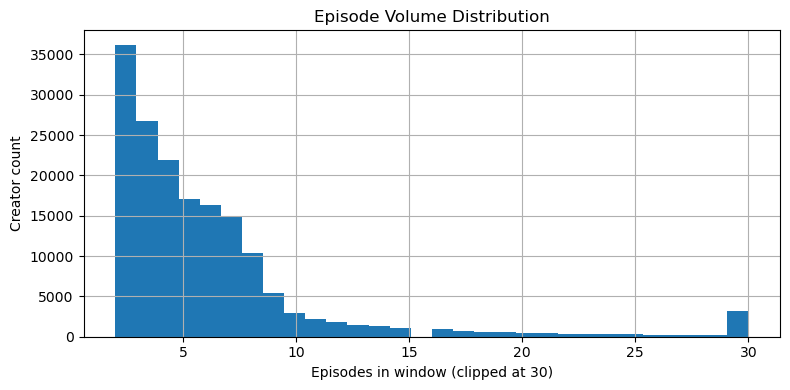

count    168619.000000
mean          6.313512
std           9.113104
min           2.000000
25%           3.000000
50%           4.000000
75%           7.000000
max        1201.000000
Name: episodes_in_window, dtype: float64


In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
creators["episodes_in_window"].clip(upper=30).hist(bins=30, ax=ax)
ax.set_xlabel("Episodes in window (clipped at 30)")
ax.set_ylabel("Creator count")
ax.set_title("Episode Volume Distribution")
plt.tight_layout()
plt.show()

print(creators["episodes_in_window"].describe())

## Category distribution

Top content categories by creator count — this becomes a meaningful stratification variable in Module 1 (categories differ significantly in survival, logrank p < 1e-290).

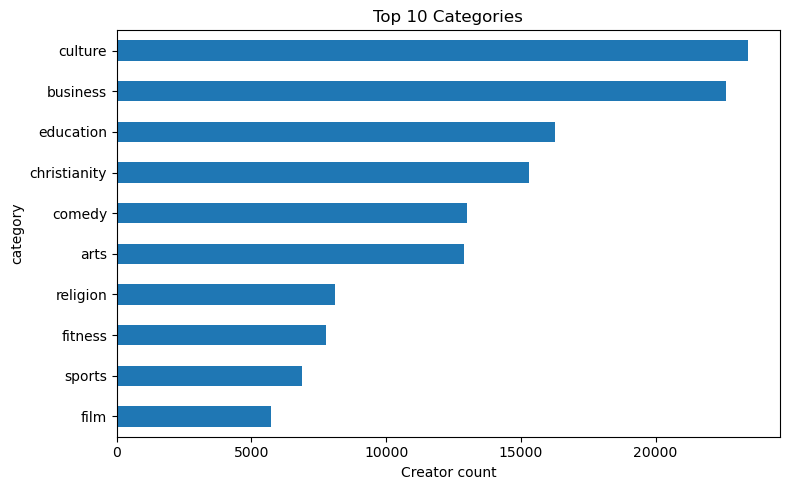

In [3]:
top_cats = creators["category"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 5))
top_cats.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Creator count")
ax.set_title("Top 10 Categories")
plt.tight_layout()
plt.show()

## Inter-episode gap distribution

This distribution is what set the "long gap" threshold used throughout the project (14 days, the ~90th percentile) — see `src/data/features.py` for the full reasoning. An earlier version used a naive 7-day threshold, which was tighter than most creators' *normal* posting cadence and produced a nonsensical median survival time near zero.

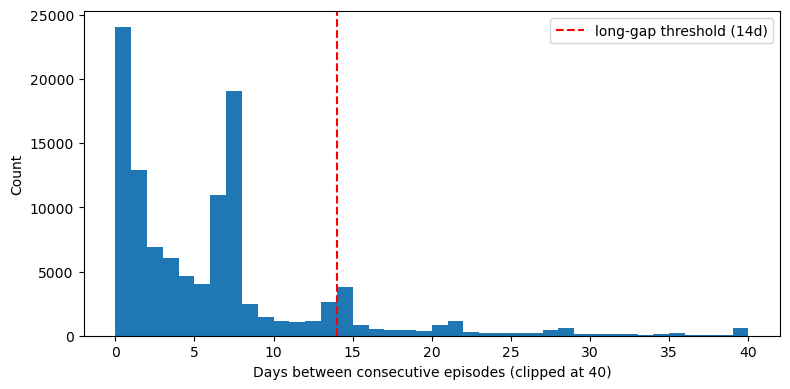

Median gap: 5.01 days, 90th percentile: 14.00 days


In [4]:
import numpy as np

all_gaps = []
for dates in creators["episode_dates"].head(20000):
    d = np.sort(pd.to_datetime(dates))
    if len(d) > 1:
        all_gaps.extend((np.diff(d) / np.timedelta64(1, "D")).tolist())
all_gaps = np.array(all_gaps)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.clip(all_gaps, 0, 40), bins=40)
ax.axvline(14, color="red", linestyle="--", label="long-gap threshold (14d)")
ax.set_xlabel("Days between consecutive episodes (clipped at 40)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median gap: {np.median(all_gaps):.2f} days, 90th percentile: {np.percentile(all_gaps, 90):.2f} days")

## Key Findings

- **168,619 creators** survive filtering (>=2 episodes, English language) out of 228,099 in the raw SPoRC catalog.
- Episode volume is heavily right-skewed: median creator posts only 4 episodes in the 61-day window.
- The 14-day "long gap" threshold is empirically justified — it sits right at the natural knee of the gap distribution (p80=8.2d, p90=14.0d), not an arbitrary rescale of the original 30-day assumption.
- This dataset is a **cross-sectional snapshot**, not longitudinal history — every module downstream is built around that constraint, not around it.